In [1]:
# header for current kernel
from pyCHX.chx_packages import *
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({ 'image.origin': 'lower'   })
plt.rcParams.update({ 'image.interpolation': 'none'   })

from decimal import Decimal
from termcolor import colored
from tqdm import tqdm

import sys
sys.path.insert(0, "/nsls2/data/chx/shared/CHX_Software/packages/standard_functions/")
sys.path.insert(0, "/nsls2/data/chx/shared/CHX_Software/packages/database_processing/")
from standard_functions import *
from database_processing import *

%run /nsls2/data/chx/shared/CHX_Software/packages/environment_management/chx_analysis_setup_test_pyCHX.ipynb

Tiled version 0.1.0a120
/nsls2/conda/envs/2024-2.0-py311-tiled/lib/python3.11/site-packages/databroker/v1.py:72: UserWarning: In databroker 2.x, there are separate notions of 'server' and 'client', and register_handler(...) has no effect on the client. Likely this is being done for you on the server side, so you should not worry about this message unless you encounter trouble loading large array data.
  warnings.warn(


running on: jupyter_hub   environment: standard

setting '_base_path_' as /nsls2/data/chx/legacy/analysis/
setting '_mask_path_' as /nsls2/data/chx/shared/CHX_Setup/Detector_masks/



Tiled version 0.1.0a120


Re-imported pyCHX from /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/
Re-imported chx_compress from /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/chx_compress.py

environment dependent settings and patches:
using "%matplotlib inline" for plotting


/nsls2/conda/envs/2024-2.0-py311-tiled/lib/python3.11/site-packages/databroker/v1.py:72: UserWarning: In databroker 2.x, there are separate notions of 'server' and 'client', and register_handler(...) has no effect on the client. Likely this is being done for you on the server side, so you should not worry about this message unless you encounter trouble loading large array data.
  warnings.warn(


### Range of uids to scan:

In [2]:
user = 'cai'
cycle = '2024_3'

scan_range = np.arange(160000,160560,dtype=int).tolist()

[s,uids]=get_uid_list(scan_range,user=user,cycle=cycle,fail_nonexisting=False,warning=False) # this will not find the data with wrong user name...

getting scan_ids/uids…: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 560/560 [01:45<00:00,  5.29it/s]



In [3]:
print(colored('Found %s uids with user=%s and cycle=%s in provided list of %s scan_ids/uids.\nGoing to check status of XPCS processing:'%(len(uids),user,cycle,len(scan_range)),'green'))
missing_dict = {}; failed_dict = {}; impossible_dict = {}
processing_not_possible = []
#for uu,u in enumerate(uids):
# for uu,u in tqdm (enumerate(uids[:20]),desc="checking status of XPCS processing…",  ascii=False, ncols=200,file=sys.stdout, colour='GREEN'):
uu=0 #tqdm doesn't seem to like enumerate
for u in tqdm (uids,desc="checking status of XPCS processing…",  ascii=False, ncols=200,file=sys.stdout, colour='GREEN'):
    try:
        [u_possible,status_dict] = check_auto_processing_possible(u,_base_path_, return_status_dict=True,verbose=False)
        #u_possible = check_auto_processing_possible(u,_base_path_,verbose=False)
    except:
        u_possible=False;status_dict={}
    if u_possible:
        h=db[u]
        expected_result_file = 'uid=%s_%s_Res.h5'%(u,h.start['analysis'])
        
        result_exists = os.path.exists(_base_path_+'/%s/%s/Results/%s/'%(cycle,user,u)+expected_result_file)
        if not result_exists:
            expected_respipeline = 'XPCS_SAXS_auto_%s.ipynb'%u
            res_pipeline_exists = os.path.exists(_base_path_+'/%s/%s/ResPipelines/'%(cycle,user)+expected_respipeline)
    else:
        processing_not_possible.append(s[uu]) # this collects lineup scans, WAXS data,...
        impossible_dict[s[uu]]={'status_dict':status_dict}
    if u_possible and not result_exists and not res_pipeline_exists: # data can be processed, but neither result.h5 nor papermill copy of notebook exists -> likely this has never been run
        missing_dict[s[uu]]={'uid':h.start['uid'],'user':h.start['user'],'sample':h.start['sample'],'Measurement':h.start['Measurement']}
    elif u_possible and not result_exists and res_pipeline_exists:   # data can be processed, papermill copy of notebook exists, but result.h5 does not -> likely this failed while running the notebook on this data
        failed_dict[s[uu]]={'uid':h.start['uid'],'user':h.start['user'],'sample':h.start['sample'],'Measurement':h.start['Measurement']}
    uu+=1

Found 560 uids with user=cai and cycle=2024_3 in provided list of 560 scan_ids/uids.
Going to check status of XPCS processing:
checking status of XPCS processing…: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 560/560 [02:33<00:00,  3.66it/s]


list of scan_ids contained 560 uids of which 560 belonged to user = cai and cycle = 2024_3


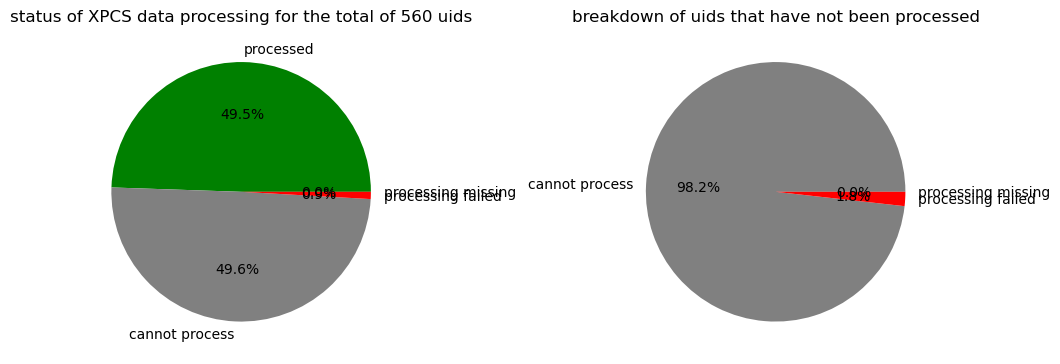

In [4]:
print(colored('list of scan_ids contained %s uids of which %s belonged to user = %s and cycle = %s'%(len(scan_range),len(uids),user,cycle),'green'))

fig,ax = plt.subplots(1,2,figsize=(10,5))
plt.subplot(1,2,1)
plt.title('status of XPCS data processing for the total of %s uids'%len(uids))
labels = ['processed','cannot process','processing failed','processing missing']
plt.pie([len(uids)-len(processing_not_possible)-len(list(failed_dict.keys()))-len(list(missing_dict.keys())),len(processing_not_possible),len(list(failed_dict.keys())),len(list(missing_dict.keys()))], labels=labels,colors=['green','gray','red','yellow'], autopct='%1.1f%%');

plt.subplot(1,2,2)
plt.title('breakdown of uids that have not been processed')
labels = ['cannot process','processing failed','processing missing']

plt.pie([len(processing_not_possible),len(list(failed_dict.keys())),len(list(missing_dict.keys()))], labels=labels,colors=['gray','red','yellow'], autopct='%1.1f%%');plt.tight_layout()

In [5]:
if True: #in case we want to know the scan_ids that cannot be processed and why they cannot be processed...
    print(colored('list of scan_ids for which XPCS data processing is NOT possible (scan might have been aborted, it might be a lineup scan or a WAXS dataset):','red'))
    for k in list(impossible_dict.keys()):
        error_desc='unknown Error'
        try:
            for s in impossible_dict[k]['status_dict'].keys():
                if not impossible_dict[k]['status_dict'][s][0]:
                    error_desc=impossible_dict[k]['status_dict'][s][1]
        except: 
            pass
        if len(list(impossible_dict[k]['status_dict'].keys())) == 0:
            try:
                h=db[k]
                h.start['plan_name']
                error_desc = 'probably not XPCS data? plan name: %s'%h.start['plan_name']
            except:
                pass
        print('scan_id: %s -> %s'%(k,error_desc))

list of scan_ids for which XPCS data processing is NOT possible (scan might have been aborted, it might be a lineup scan or a WAXS dataset):
scan_id: 160001 -> probably not XPCS data? plan name: count
scan_id: 160003 -> probably not XPCS data? plan name: count
scan_id: 160005 -> probably not XPCS data? plan name: count
scan_id: 160007 -> probably not XPCS data? plan name: count
scan_id: 160009 -> probably not XPCS data? plan name: count
scan_id: 160011 -> probably not XPCS data? plan name: count
scan_id: 160013 -> probably not XPCS data? plan name: count
scan_id: 160015 -> probably not XPCS data? plan name: count
scan_id: 160017 -> probably not XPCS data? plan name: count
scan_id: 160019 -> probably not XPCS data? plan name: count
scan_id: 160021 -> probably not XPCS data? plan name: count
scan_id: 160023 -> probably not XPCS data? plan name: count
scan_id: 160025 -> probably not XPCS data? plan name: count
scan_id: 160027 -> probably not XPCS data? plan name: count
scan_id: 160029 -> 

In [6]:
print(colored('list of scan_ids for which XPCS data processing is missing, but should be feasible:','green'))
for k in np.array(list(missing_dict.keys())):
    h=db[missing_dict[k]['uid']]
    print('scan_id: %s -> %s'%(k,h.start['Measurement']))

list of scan_ids for which XPCS data processing is missing, but should be feasible:


In [7]:
print(colored('list of scan_ids for which XPCS data processing failed:','red'))

print_str=''
for k in tqdm (list(failed_dict.keys()),desc="details of scan_ids that failed XPCS processing…",  ascii=False, ncols=200,file=sys.stdout, colour='GREEN'):
    display(clear=True,wait =True)
    h=db[failed_dict[k]['uid']]
    print_str+='scan_id: %s -> %s\n'%(k,h.start['Measurement'])
    #print('scan_id: %s -> %s'%(k,h.start['Measurement']))
    print(print_str)

scan_id: 160202 ->  1s x 20 fr. Trans:1.0 sample: Sample1-BzMA4.72-Slide2-3 s3
scan_id: 160204 ->  1s x 20 fr. Trans:1.0 sample: Sample1-BzMA4.72-Slide2-4 s4
scan_id: 160244 ->  1s x 20 fr. Trans:1.0 sample: MSU-set1-sample1-L1 L1
scan_id: 160247 ->  1s x 20 fr. Trans:1.0 sample: MSU-set1-sample1-L2 L2
scan_id: 160328 ->  1s x 20 fr. Trans:1.0 sample: MSU-set3-sample14-L2 L2

details of scan_ids that failed XPCS processing…: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  5.36it/s]


### Look at a random image from the failed scan_ids: [note: checking for intensity in detector region might only work correctly for the 4M]

getting random image from dataset…: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:24<00:00,  4.95s/it]


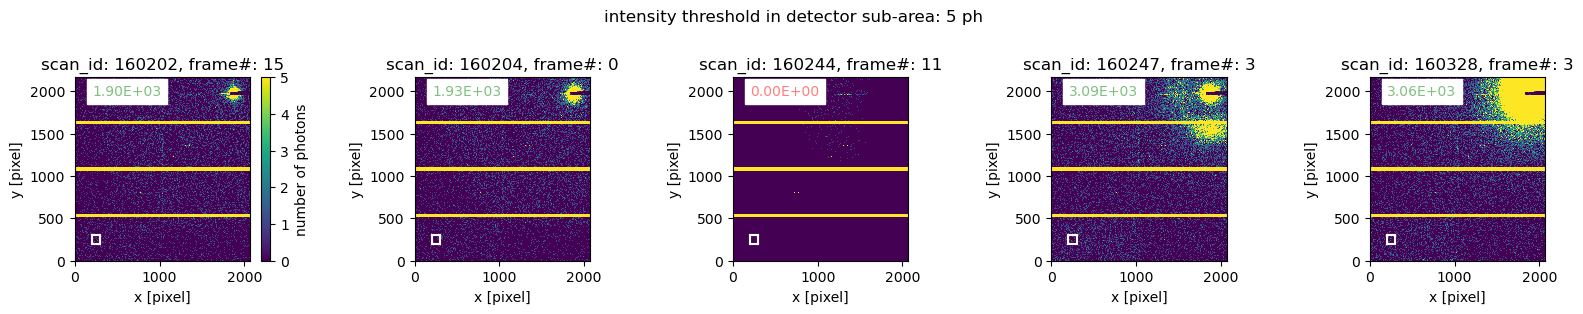

In [10]:
int_threshold = 5 #threshold minimum number of photons in selected detector area to deem reprocessing the dataset worthwhile
retry_dict = {}
ncols = 5
nrows = int(np.ceil(len(list(failed_dict.keys()))/ncols))
fig,ax = plt.subplots(nrows,ncols,figsize=(16,3*nrows))
plt.suptitle('intensity threshold in detector sub-area: %s ph'%int_threshold,y=1.02)
pc=1;ii=0
for i in tqdm (list(failed_dict.keys()),desc="getting random image from dataset…",  ascii=False, ncols=200,file=sys.stdout, colour='GREEN'):
# for ii,i in enumerate(list(failed_dict.keys())):
    try:
        md=get_meta_data(i,verbose=False)
        imgs,img_md=load_dask_data(md['uid'],md['detector'], _mask_path_+'pixel_masks/',reverse=False,rot90=False)
        rn=random.randint(0,np.shape(imgs)[0]-1)
        plt.subplot(nrows,ncols,pc);pc+=1
        photon_count = float(np.sum(np.sum(imgs[rn,200:300,200:300],axis=1))) # this has only been tested for the 4M yet
        if photon_count > 5:
            lab_col='green'
            retry_dict[i]={'uid':md['uid'],'user':md['user'],'sample':md['sample'],'Measurement':md['Measurement']}
        else: lab_col = 'red'
        plt.imshow(imgs[rn,:,:],vmin=0,vmax=5);plt.xlabel('x [pixel]');plt.ylabel('y [pixel]');plt.title('scan_id: %s, frame#: %s'%(i,rn))
        plt.plot([200,200],[200,300],'-',color='white');plt.plot([300,300],[200,300],'-',color='white')
        plt.plot([200,300],[200,200],'-',color='white');plt.plot([200,300],[300,300],'-',color='white')
        ax=plt.gca()
        plt.text(0.1, 0.9, '%.2E' % Decimal(str(photon_count)), fontsize=10,color=lab_col, backgroundcolor='white',alpha=.5, transform=ax.transAxes)
        if ii == 0:
            plt.colorbar(label='number of photons')
    except:
        plt.subplot(nrows,ncols,pc);pc+=1
        plt.title('scan_id: %s -> failed to load data'%(i))
    ii+=1
for i in range(nrows*ncols-pc+1):
    plt.subplot(nrows,ncols,pc);pc+=1
    ax=plt.gca();ax.set_axis_off()
plt.tight_layout()

### Save dictionary for re-processing via CHX_ReRun_Batch_Processing

In [11]:
if False:
    try:
        fn = '%s_%s_reprocessing.pkl'%(user,cycle)
        sp='%s/%s/%s/'%(_base_path_,cycle,user)
        save_dict={'missing':missing_dict,'retry':retry_dict,'impossible':impossible_dict,'failed':failed_dict}
        save_pickle(sp+fn,save_dict)
        print('Successfully saved dictionary with udis for re-processing as %s.'%(sp+fn))
    except:
        raise Exception('Something went wrong...dictionary has not been saved')
else:
    print('Dictionary has not been saved...set "if True" if you want to save it.')

Successfully saved dictionary with udis for re-processing as /nsls2/data/chx/legacy/analysis//2024_3/cai/cai_2024_3_reprocessing.pkl.
